
# Módulo 8 — Pipeline prático de ajuste de modelos (da experimentação à produção)

> **Tema:** protocolo de experimentos, receita de depuração, seleção robusta de configuração e checklist de produção/reprodutibilidade.  
> **Objetivo didático:** fechar o curso com um fluxo completo e replicável para treinar, comparar, escolher e preparar um modelo profundo para uso real.

---

## Roteiro da aula

1. Protocolo de experimentos (sem vazamento)  
2. Baseline + duas configurações candidatas  
3. Comparação com múltiplas seeds  
4. Receita de depuração quando “o modelo não aprende”  
5. Seleção final com justificativa técnica  
6. Export de artefatos e checklist de produção



## 0) Setup

Notebook leve (CPU) com PyTorch + dataset sintético de classificação binária.


In [27]:

# =========================
# Setup e bibliotecas
# =========================
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, brier_score_loss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu



## 1) Funções utilitárias de reprodutibilidade e métricas

Incluímos:
- fixação de seed,
- ECE (Expected Calibration Error),
- cálculo consolidado de métricas.


In [28]:

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        else:
            mask = (y_prob >= bins[i]) & (y_prob <= bins[i+1])
        if np.any(mask):
            conf = np.mean(y_prob[mask])
            acc = np.mean(y_true[mask])
            ece += (np.sum(mask) / len(y_true)) * np.abs(acc - conf)
    return float(ece)

def compute_metrics(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    return {
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "ece": expected_calibration_error(y_true, y_prob, n_bins=10)
    }



## 2) Dados: cenário IID e cenário com shift de distribuição

Criamos:
- `test_iid`: mesma distribuição do treino  
- `test_shift`: ruído + drift em algumas features (simulação de produção)


In [29]:

seed_everything(42)

X, y = make_classification(
    n_samples=2500,
    n_features=20,
    n_informative=12,
    n_redundant=4,
    n_repeated=0,
    n_classes=2,
    weights=[0.65, 0.35],
    class_sep=1.0,
    flip_y=0.03,
    random_state=42
)

# Split principal: train / val / test_iid
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=42
)
X_val, X_test_iid, y_val, y_test_iid = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# Test shift: ruído + escala em algumas colunas
rng = np.random.default_rng(123)
X_test_shift = X_test_iid.copy()
X_test_shift = X_test_shift + rng.normal(0, 0.60, size=X_test_shift.shape)
X_test_shift[:, :5] = 1.20 * X_test_shift[:, :5] + 0.20

print("Train:", X_train.shape, "Val:", X_val.shape, "Test IID:", X_test_iid.shape, "Test Shift:", X_test_shift.shape)


Train: (1500, 20) Val: (500, 20) Test IID: (500, 20) Test Shift: (500, 20)



## 3) Dataloaders com padronização correta (sem leakage)

O `StandardScaler` é ajustado **somente no treino**.


In [30]:

def make_loaders(X_tr, y_tr, X_va, y_va, batch_size=64, scaler=None, fit_scaler=True):
    if scaler is None:
        scaler = StandardScaler()

    if fit_scaler:
        X_tr_s = scaler.fit_transform(X_tr)
    else:
        X_tr_s = scaler.transform(X_tr)

    X_va_s = scaler.transform(X_va)

    Xtr_t = torch.tensor(X_tr_s, dtype=torch.float32)
    ytr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
    Xva_t = torch.tensor(X_va_s, dtype=torch.float32)
    yva_t = torch.tensor(y_va, dtype=torch.float32).unsqueeze(1)

    train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=256, shuffle=False)
    return train_loader, val_loader, scaler



## 4) Modelo MLP configurável

Vamos variar capacidade (profundidade/largura), dropout e otimização.


In [31]:

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.1):
        super().__init__()
        layers = []
        d = input_dim
        for _ in range(num_layers):
            layers += [nn.Linear(d, hidden_dim), nn.ReLU(), nn.Dropout(dropout)]
            d = hidden_dim
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)



## 5) Treino com early stopping + scheduler (opcional)

Esse bloco será o coração do nosso protocolo de experimentos.


In [32]:

def evaluate_loader(model, loader):
    model.eval()
    losses, probs, ys = [], [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            p = torch.sigmoid(logits)

            losses.append(loss.item())
            probs.append(p.cpu().numpy().ravel())
            ys.append(yb.cpu().numpy().ravel())

    y_true = np.concatenate(ys)
    y_prob = np.concatenate(probs)
    m = compute_metrics(y_true, y_prob, thr=0.5)
    m["loss"] = float(np.mean(losses))
    return m

def train_one_run(X_tr, y_tr, X_va, y_va, cfg, seed=42, max_epochs=50, patience=8):
    seed_everything(seed)

    train_loader, val_loader, scaler = make_loaders(
        X_tr, y_tr, X_va, y_va,
        batch_size=cfg["batch_size"],
        scaler=None,
        fit_scaler=True
    )

    model = MLP(
        input_dim=X_tr.shape[1],
        hidden_dim=cfg["hidden_dim"],
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"]
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"]
    )

    scheduler = None
    if cfg.get("use_cosine", False):
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=cfg["lr"] * 0.05)

    best_state = None
    best_val_loss = float("inf")
    best_epoch = 0
    wait = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_auc": [],
        "val_f1": [],
        "lr": []
    }

    for epoch in range(1, max_epochs + 1):
        model.train()
        batch_losses = []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        if scheduler is not None:
            scheduler.step()

        val_m = evaluate_loader(model, val_loader)

        history["train_loss"].append(float(np.mean(batch_losses)))
        history["val_loss"].append(val_m["loss"])
        history["val_auc"].append(val_m["auc"])
        history["val_f1"].append(val_m["f1"])
        history["lr"].append(float(optimizer.param_groups[0]["lr"]))

        if val_m["loss"] < best_val_loss - 1e-4:
            best_val_loss = val_m["loss"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    model.load_state_dict(best_state)
    final_val = evaluate_loader(model, val_loader)

    return model, scaler, history, final_val, best_epoch



## 6) Protocolo de experimentos (mini-estudo de caso)

Vamos comparar 3 configurações:

- `baseline`  
- `alta_capacidade` (maior modelo)  
- `regularizada` (mais dropout/weight decay)

Cada uma com **3 seeds** para reduzir conclusões acidentais.


In [33]:

configs = {
    "baseline": {
        "hidden_dim": 64,
        "num_layers": 2,
        "dropout": 0.10,
        "lr": 1e-3,
        "weight_decay": 1e-3,
        "batch_size": 64,
        "use_cosine": True
    },
    "alta_capacidade": {
        "hidden_dim": 128,
        "num_layers": 3,
        "dropout": 0.10,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 64,
        "use_cosine": True
    },
    "regularizada": {
        "hidden_dim": 64,
        "num_layers": 2,
        "dropout": 0.30,
        "lr": 8e-4,
        "weight_decay": 5e-3,
        "batch_size": 64,
        "use_cosine": True
    }
}

seeds = [11, 22, 33]
rows = []
histories_store = {}

for cfg_name, cfg in configs.items():
    for s in seeds:
        model, scaler, hist, val_m, best_epoch = train_one_run(
            X_train, y_train, X_val, y_val, cfg,
            seed=s, max_epochs=45, patience=8
        )

        # Avaliar nos dois testes
        _, test_iid_loader, _ = make_loaders(X_train, y_train, X_test_iid, y_test_iid, batch_size=128, scaler=scaler, fit_scaler=False)
        _, test_shift_loader, _ = make_loaders(X_train, y_train, X_test_shift, y_test_iid, batch_size=128, scaler=scaler, fit_scaler=False)

        test_iid_m = evaluate_loader(model, test_iid_loader)
        test_shift_m = evaluate_loader(model, test_shift_loader)

        rows.append({
            "config": cfg_name,
            "seed": s,
            "best_epoch": best_epoch,
            "val_auc": val_m["auc"],
            "val_f1": val_m["f1"],
            "test_iid_auc": test_iid_m["auc"],
            "test_iid_f1": test_iid_m["f1"],
            "test_shift_auc": test_shift_m["auc"],
            "test_shift_f1": test_shift_m["f1"],
            "robust_gap_auc": test_iid_m["auc"] - test_shift_m["auc"],
        })

        histories_store[(cfg_name, s)] = hist

df_runs = pd.DataFrame(rows)
display(df_runs.head())


,config,seed,best_epoch,val_auc,val_f1,test_iid_auc,test_iid_f1,test_shift_auc,test_shift_f1,robust_gap_auc
0,baseline,11,24,0.975984,0.923977,0.964038,0.916427,0.966347,0.897959,-0.002309
1,baseline,22,30,0.974410,0.902655,0.967291,0.920000,0.969617,0.896552,-0.002326
2,baseline,33,30,0.976666,0.911243,0.962306,0.912281,0.961292,0.893491,0.001015
3,alta_capacidade,11,13,0.982928,0.946479,0.969845,0.923513,0.970929,0.913165,-0.001084
4,alta_capacidade,22,12,0.980742,0.921283,0.966487,0.906977,0.968376,0.893372,-0.001889


In [34]:

# Agregação média e desvio por configuração
agg = df_runs.groupby("config").agg(
    val_auc_mean=("val_auc", "mean"),
    val_auc_std=("val_auc", "std"),
    val_f1_mean=("val_f1", "mean"),
    test_iid_auc_mean=("test_iid_auc", "mean"),
    test_iid_f1_mean=("test_iid_f1", "mean"),
    test_shift_auc_mean=("test_shift_auc", "mean"),
    test_shift_f1_mean=("test_shift_f1", "mean"),
    robust_gap_auc_mean=("robust_gap_auc", "mean"),
).sort_values(["test_shift_auc_mean", "val_auc_mean"], ascending=False)

display(agg)


,val_auc_mean,val_auc_std,val_f1_mean,test_iid_auc_mean,test_iid_f1_mean,test_shift_auc_mean,test_shift_f1_mean,robust_gap_auc_mean
config,,,,,,,,
alta_capacidade,0.981354,0.001374,0.933193,0.967443,0.918875,0.968708,0.904173,-0.001265
baseline,0.975687,0.001157,0.912625,0.964545,0.916236,0.965752,0.896001,-0.001207
regularizada,0.968393,0.000684,0.903942,0.958190,0.904746,0.959997,0.895059,-0.001807



### Critério de escolha (exemplo didático)

Para produção, vamos priorizar:
1. desempenho em `test_shift_auc_mean`,
2. e menor `robust_gap_auc_mean`.


In [35]:

best_config_name = agg.index[0]
best_config = configs[best_config_name]
print("Configuração selecionada:", best_config_name)
best_config


Configuração selecionada: alta_capacidade


{'hidden_dim': 128,
 'num_layers': 3,
 'dropout': 0.1,
 'lr': 0.001,
 'weight_decay': 0.0001,
 'batch_size': 64,
 'use_cosine': True}


## 7) Curvas de treino (run representativa)

Vamos visualizar uma execução representativa da configuração escolhida.


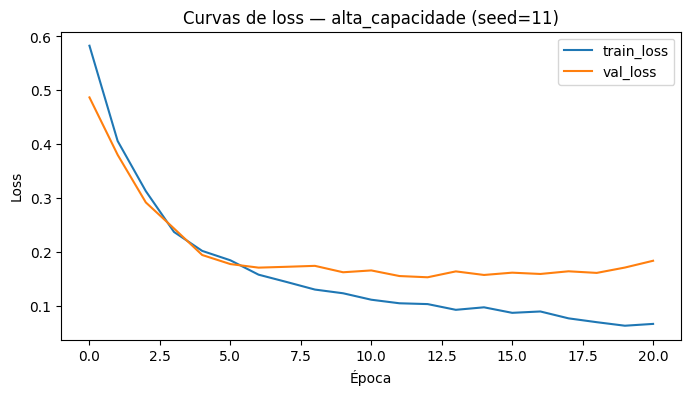

In [36]:

rep_seed = seeds[0]
hist_rep = histories_store[(best_config_name, rep_seed)]

plt.figure(figsize=(8, 4))
plt.plot(hist_rep["train_loss"], label="train_loss")
plt.plot(hist_rep["val_loss"], label="val_loss")
plt.title(f"Curvas de loss — {best_config_name} (seed={rep_seed})")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()


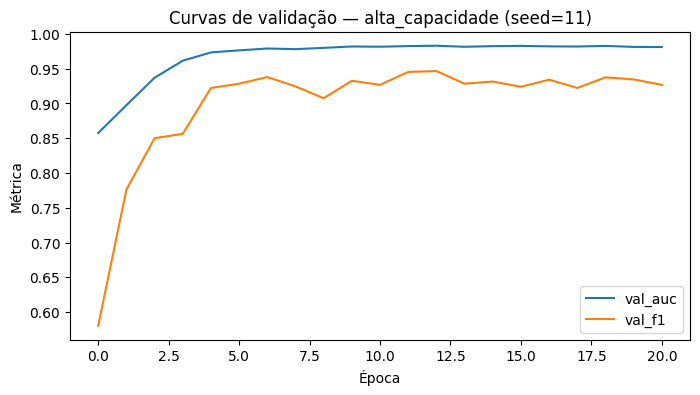

In [37]:

plt.figure(figsize=(8, 4))
plt.plot(hist_rep["val_auc"], label="val_auc")
plt.plot(hist_rep["val_f1"], label="val_f1")
plt.title(f"Curvas de validação — {best_config_name} (seed={rep_seed})")
plt.xlabel("Época")
plt.ylabel("Métrica")
plt.legend()
plt.show()


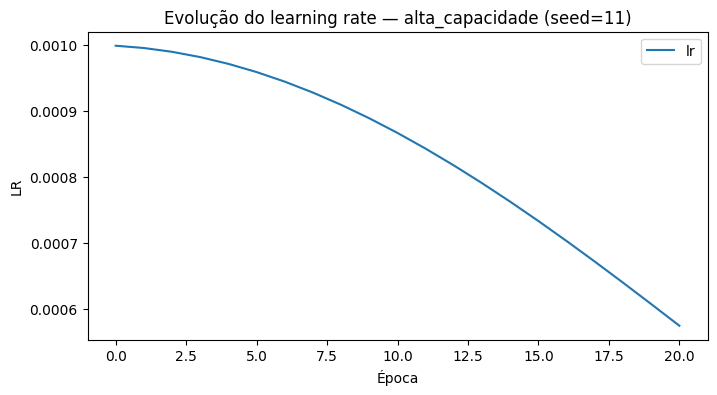

In [38]:

plt.figure(figsize=(8, 4))
plt.plot(hist_rep["lr"], label="lr")
plt.title(f"Evolução do learning rate — {best_config_name} (seed={rep_seed})")
plt.xlabel("Época")
plt.ylabel("LR")
plt.legend()
plt.show()



## 8) Receita de depuração — quando “o modelo não aprende”

Vamos comparar rapidamente três LRs:
- muito baixo (`1e-6`)
- adequado (`1e-3`)
- muito alto (`5e-2`)


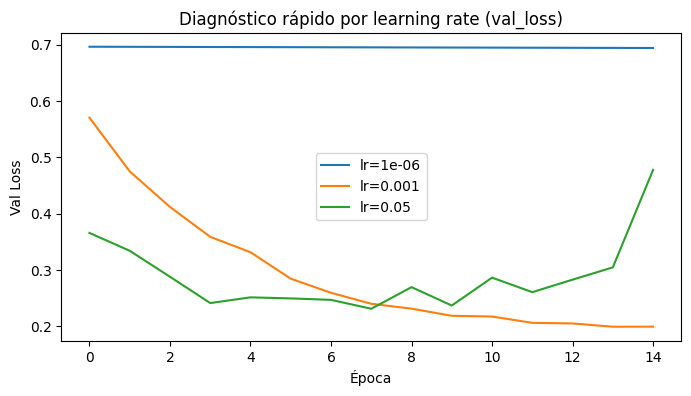

In [39]:

def lr_diagnosis(lrs, epochs=15):
    curves = {}
    base_cfg = {
        "hidden_dim": 64,
        "num_layers": 2,
        "dropout": 0.1,
        "weight_decay": 1e-3,
        "batch_size": 64,
        "use_cosine": False
    }
    for lr in lrs:
        cfg = dict(base_cfg)
        cfg["lr"] = lr
        _, _, hist, _, _ = train_one_run(
            X_train, y_train, X_val, y_val, cfg,
            seed=99, max_epochs=epochs, patience=epochs
        )
        curves[lr] = hist["val_loss"]
    return curves

curves = lr_diagnosis([1e-6, 1e-3, 5e-2], epochs=15)

plt.figure(figsize=(8, 4))
for lr, v in curves.items():
    plt.plot(v, label=f"lr={lr}")
plt.title("Diagnóstico rápido por learning rate (val_loss)")
plt.xlabel("Época")
plt.ylabel("Val Loss")
plt.legend()
plt.show()



### Checklist de depuração (ordem prática)

1. **Sanity check de dados**: shape, rótulos, balanceamento, escala.  
2. **Overfit em lote pequeno**: o modelo consegue memorizar 64–128 exemplos?  
3. **LR test**: validar ordem de grandeza do learning rate.  
4. **Capacidade**: aumentar/diminuir largura/profundidade conforme under/overfitting.  
5. **Regularização**: ajustar dropout/weight decay só depois de LR estável.  
6. **Métrica certa**: usar AUC/F1/ECE além de acurácia.  
7. **Seeds múltiplas**: confirmar estabilidade antes de decidir.



## 9) Treino final e geração de artefatos para produção

Agora treinamos a configuração escolhida no bloco `train+val` (com split interno para early stopping),
avaliamos no teste e salvamos:

- `model.pt` (pesos PyTorch)
- `model_scripted.pt` (TorchScript)
- `scaler_mean.npy`, `scaler_scale.npy`
- `config.json`
- `metrics.json`
- `runs.csv` e `summary.csv`


In [40]:

# Split interno para early stopping no treino final
X_tr_final, X_va_final, y_tr_final, y_va_final = train_test_split(
    np.vstack([X_train, X_val]),
    np.concatenate([y_train, y_val]),
    test_size=0.15,
    stratify=np.concatenate([y_train, y_val]),
    random_state=123
)

final_model, final_scaler, final_hist, final_val_m, final_best_epoch = train_one_run(
    X_tr_final, y_tr_final, X_va_final, y_va_final,
    best_config, seed=2026, max_epochs=60, patience=10
)

_, final_test_iid_loader, _ = make_loaders(
    X_tr_final, y_tr_final, X_test_iid, y_test_iid,
    batch_size=256, scaler=final_scaler, fit_scaler=False
)
_, final_test_shift_loader, _ = make_loaders(
    X_tr_final, y_tr_final, X_test_shift, y_test_iid,
    batch_size=256, scaler=final_scaler, fit_scaler=False
)

final_test_iid_m = evaluate_loader(final_model, final_test_iid_loader)
final_test_shift_m = evaluate_loader(final_model, final_test_shift_loader)

print("Final TEST IID :", final_test_iid_m)
print("Final TEST SHIFT:", final_test_shift_m)


Final TEST IID : {'acc': 0.942, 'f1': 0.9173789173789174, 'auc': 0.9704045757464448, 'brier': 0.04709206521511078, 'ece': 0.021812379371374844, 'loss': 0.19217918068170547}
Final TEST SHIFT: {'acc': 0.918, 'f1': 0.8825214899713467, 'auc': 0.9708243689982684, 'brier': 0.05814036726951599, 'ece': 0.022172174260020255, 'loss': 0.20770704746246338}


In [41]:
artifact_dir = "./Modulo8_artefatos_pipeline"
os.makedirs(artifact_dir, exist_ok=True)

# 1) Pesos PyTorch
torch.save(final_model.state_dict(), os.path.join(artifact_dir, "model.pt"))

# 2) TorchScript
final_model_cpu = final_model.to("cpu").eval()
example_input = torch.randn(1, X_train.shape[1], dtype=torch.float32)
scripted = torch.jit.trace(final_model_cpu, example_input)
scripted.save(os.path.join(artifact_dir, "model_scripted.pt"))

# 3) Scaler
np.save(os.path.join(artifact_dir, "scaler_mean.npy"), final_scaler.mean_)
np.save(os.path.join(artifact_dir, "scaler_scale.npy"), final_scaler.scale_)

# 4) Config e métricas
with open(os.path.join(artifact_dir, "config.json"), "w", encoding="utf-8") as f:
    json.dump({"selected_config_name": best_config_name, "config": best_config}, f, indent=2, ensure_ascii=False)

metrics_payload = {
    "final_val": final_val_m,
    "final_test_iid": final_test_iid_m,
    "final_test_shift": final_test_shift_m,
    "final_best_epoch": int(final_best_epoch)
}
with open(os.path.join(artifact_dir, "metrics.json"), "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, indent=2, ensure_ascii=False)

# 5) Logs tabulares
df_runs.to_csv(os.path.join(artifact_dir, "runs.csv"), index=False)
agg.reset_index().to_csv(os.path.join(artifact_dir, "summary.csv"), index=False)

print("Artefatos salvos em:", artifact_dir)
print("Arquivos:", sorted(os.listdir(artifact_dir)))

Artefatos salvos em: ./Modulo8_artefatos_pipeline
Arquivos: ['Bank_Churn.csv', 'config.json', 'metrics.json', 'model.pt', 'model_scripted.pt', 'runs.csv', 'scaler_mean.npy', 'scaler_scale.npy', 'summary.csv']



## 10) Função de inferência (produção)

Exemplo de predição com preprocessing consistente.


In [42]:

def predict_proba_numpy(X_raw, model, scaler, device=device):
    model.eval()
    X_s = scaler.transform(X_raw)
    Xt = torch.tensor(X_s, dtype=torch.float32).to(device)
    with torch.no_grad():
        p = torch.sigmoid(model(Xt)).cpu().numpy().ravel()
    return p

# Exemplo rápido
sample_probs = predict_proba_numpy(X_test_iid[:5], final_model.to(device), final_scaler, device=device)
sample_preds = (sample_probs >= 0.5).astype(int)

print("Probabilidades:", np.round(sample_probs, 4))
print("Predições     :", sample_preds)
print("Rótulos reais :", y_test_iid[:5])


Probabilidades: [0.0015 0.0247 0.9718 0.2559 0.0021]
Predições     : [0 0 1 0 0]
Rótulos reais : [0 0 1 1 0]



## 11) Checklist final de boas práticas para produção

### Reprodutibilidade
- Fixar seeds e versionar `config.json`.
- Salvar métricas por execução (`runs.csv`) e agregado (`summary.csv`).
- Registrar ambiente (versões de libs, hardware).

### Qualidade de modelo
- Selecionar por métrica alinhada ao negócio (não só acurácia).
- Validar com múltiplas seeds.
- Medir robustez fora da distribuição (shift tests).
- Avaliar calibração (ECE/Brier), não apenas discriminação (AUC).

### Engenharia de deployment
- Exportar artefato de inferência (TorchScript/ONNX).
- Congelar preprocessing (scaler/tokenizer) junto com o modelo.
- Criar testes de regressão para pipeline de predição.
- Monitorar drift e queda de performance em produção.


### O Painel de Controle: Monitoramento de Data Drift

O maior pesadelo em produção é o "Data Drift" (os dados mudam silenciosamente e o modelo emburrece).
Este experimento simula um dashboard de monitoramento em tempo real.

* Visual: O aluno verá a distribuição dos dados de "Ontem" (Treino) vs "Hoje" (Produção).

* Alerta: Quando a distância (KL Divergence) passa do limite, um alerta vermelho dispara.

In [43]:
# Experimento 1: Dashboard de Monitoramento de Drift (Produção Real)
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
from ipywidgets import interact, FloatSlider

def visualize_data_drift(drift_severity=0.0):
    # 1. Dados de Referência (Treino - Ontem)
    # Distribuição Normal Padrão (Média 0, Std 1)
    np.random.seed(42)
    ref_data = np.random.normal(0, 1, 1000)

    # 2. Dados de Produção (Hoje)
    # Simula um deslocamento na média (Drift)
    prod_data = np.random.normal(0 + drift_severity * 2, 1, 1000)

    # 3. Cálculo de Drift (Kullback-Leibler Divergence)
    # Discretizar para calcular entropia
    bins = np.linspace(-4, 6, 20)
    ref_hist, _ = np.histogram(ref_data, bins=bins, density=True)
    prod_hist, _ = np.histogram(prod_data, bins=bins, density=True)

    # Evitar divisão por zero
    ref_hist = ref_hist + 1e-5
    prod_hist = prod_hist + 1e-5

    # KL Divergence: Quanto P (Prod) diverge de Q (Ref)?
    kl_div = entropy(prod_hist, ref_hist)

    # Limiar de Alerta (Threshold comum na indústria: 0.1 a 0.2)
    threshold = 0.15
    status = "NORMAL" if kl_div < threshold else "DRIFT DETECTADO 🚨"
    color = "green" if kl_div < threshold else "red"

    # 4. Visualização (Dashboard)
    fig, ax = plt.subplots(figsize=(10, 5))

    # Plotar as distribuições
    ax.hist(ref_data, bins=bins, alpha=0.5, label='Referência (Treino)', color='blue', density=True)
    ax.hist(prod_data, bins=bins, alpha=0.5, label='Produção (Hoje)', color='orange', density=True)

    # Linhas de Média
    ax.axvline(np.mean(ref_data), color='blue', linestyle='--')
    ax.axvline(np.mean(prod_data), color='orange', linestyle='--')

    # Caixa de Status
    props = dict(boxstyle='round', facecolor=color, alpha=0.2)
    ax.text(0.02, 0.95, f"Status: {status}\nKL Divergence: {kl_div:.4f}\nThreshold: {threshold}",
            transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=props)

    ax.set_title("Monitoramento de Feature Drift (PSI / KL)")
    ax.set_xlabel("Valor da Feature")
    ax.set_ylabel("Densidade")
    ax.legend()
    plt.show()

print("Mova o slider para simular que os dados de produção mudaram.")
print("Observe quando o 'KL Divergence' cruza o limite e o alerta dispara.")

interact(visualize_data_drift,
         drift_severity=FloatSlider(min=0.0, max=1.0, step=0.1, value=0.0, description='Intensidade do Shift'));

Mova o slider para simular que os dados de produção mudaram.
Observe quando o 'KL Divergence' cruza o limite e o alerta dispara.


interactive(children=(FloatSlider(value=0.0, description='Intensidade do Shift', max=1.0), Output()), _dom_cla…

### O Raio-X do Modelo: SHAP Values (Explainability)

Não basta dizer "O modelo errou". Precisamos saber por que.
No SOTA, usamos SHAP (SHapley Additive exPlanations).
Este experimento cria uma visualização simplificada de SHAP para mostrar quais features empurraram a decisão para "Positivo" ou "Negativo".

* Cenário: Aprovar Crédito.

* Visual: Barras vermelhas empurram para "Negar", Azuis para "Aprovar".

In [44]:
# Experimento 2: Por que o modelo decidiu isso? (SHAP Simplificado)
# Mostra a contribuição de cada feature para a decisão final.

from ipywidgets import interact, IntSlider

def explain_prediction(renda=5000, idade=30, divida=1000):
    # Modelo Dummy (Regressão Logística Simulada)
    # Score = w1*Renda + w2*Idade + w3*Divida + bias
    # Pesos (O modelo "aprendeu" isso):
    # Renda alta ajuda (+), Idade ajuda um pouco (+), Dívida atrapalha muito (-)

    base_value = 0.0 # Bias

    # Contribuições (SHAP Values simulados)
    # Normalizamos para escalas visuais
    shap_renda = (renda - 3000) * 0.0005  # Renda média 3000
    shap_idade = (idade - 40) * 0.02      # Idade média 40
    shap_divida = -(divida - 500) * 0.002 # Dívida média 500

    total_score = base_value + shap_renda + shap_idade + shap_divida
    probabilidade = 1 / (1 + np.exp(-total_score)) # Sigmoid

    # Visualização Waterfall (Estilo SHAP)
    features = ['Renda', 'Idade', 'Dívida']
    values = [shap_renda, shap_idade, shap_divida]

    fig, ax = plt.subplots(figsize=(10, 4))

    # Começa do zero (Bias)
    curr = base_value

    for i, (feat, val) in enumerate(zip(features, values)):
        color = 'dodgerblue' if val > 0 else 'crimson'
        ax.barh(feat, val, left=curr, color=color, alpha=0.8)
        # Anotar valor
        ax.text(curr + val/2, i, f"{val:+.2f}", va='center', ha='center', color='white', fontweight='bold')
        curr += val

    # Linha final
    ax.axvline(0, color='gray', linestyle='--')
    ax.set_xlim(-3, 3)
    ax.set_title(f"Explicação da Decisão (Score: {total_score:.2f} | Prob: {probabilidade:.1%})")
    ax.set_xlabel("Impacto no Log-Odds (← Negar | Aprovar →)")

    plt.show()

    print("Azul empurra para Aprovar. Vermelho empurra para Negar.")
    print("Veja como uma Dívida alta (vermelho grande) pode anular uma Renda alta (azul).")

interact(explain_prediction,
         renda=FloatSlider(min=1000, max=10000, step=500, value=5000),
         idade=IntSlider(min=18, max=80, step=1, value=30),
         divida=FloatSlider(min=0, max=5000, step=100, value=1000));

interactive(children=(FloatSlider(value=5000.0, description='renda', max=10000.0, min=1000.0, step=500.0), Int…

### O Teste A/B Estatístico (Comparação SOTA)

As vezes escolhemos o Modelo A porque a acurácia foi 85.2% contra 85.1% do Modelo B. Isso é errado.
No SOTA, usamos testes de hipótese (ou Bootstrap) para saber se a diferença é real ou ruído.

Este widget mostra duas distribuições de performance (simulando 30 seeds diferentes).

* Sobreposição: Se as curvas se cruzam muito, a diferença não é significativa.

* p-valor: Calculamos na hora a chance de ser sorte.

In [45]:
# Experimento 3: A Diferença é Real? (Teste de Significância)
from scipy import stats

def compare_models_statistically(diff_strength=0.5, variance=0.5):
    # Simula 30 runs (seeds) para cada modelo
    np.random.seed(42)

    # Modelo A (Baseline)
    scores_a = np.random.normal(85.0, variance, 30)

    # Modelo B (Candidato) - É 'diff_strength' melhor na média
    scores_b = np.random.normal(85.0 + diff_strength, variance, 30)

    # Teste T de Student (Independente)
    t_stat, p_val = stats.ttest_ind(scores_b, scores_a)

    # Visualização
    fig, ax = plt.subplots(figsize=(10, 5))

    # Histogramas
    ax.hist(scores_a, alpha=0.6, label='Modelo A (Base)', color='gray', bins=10)
    ax.hist(scores_b, alpha=0.6, label='Modelo B (Novo)', color='green', bins=10)

    # Médias
    ax.axvline(np.mean(scores_a), color='gray', linestyle='--', linewidth=2)
    ax.axvline(np.mean(scores_b), color='green', linestyle='--', linewidth=2)

    # Decisão Estatística
    alpha = 0.05 # 95% de confiança
    significativo = p_val < alpha

    if significativo:
        decision = "DIFERENÇA REAL (Estatisticamente Significativa)"
        box_color = '#d5f5e3'
    else:
        decision = "EMPATE TÉCNICO (Ruído aleatório)"
        box_color = '#fadbd8'

    ax.set_title(f"Comparação de 30 Seeds: A vs B")
    ax.set_xlabel("Acurácia (%)")
    ax.legend()

    # Relatório
    report = (f"Média A: {np.mean(scores_a):.2f}%\n"
              f"Média B: {np.mean(scores_b):.2f}%\n"
              f"P-valor: {p_val:.4f}\n\n"
              f"{decision}")

    ax.text(1.02, 0.5, report, transform=ax.transAxes, va='center',
            bbox=dict(boxstyle='round', facecolor=box_color))

    plt.tight_layout()
    plt.show()

    print("Em ML SOTA, nunca olhamos apenas uma execução.")
    print("Se o P-valor for > 0.05 (caixa vermelha), você não pode dizer que o Modelo B é melhor.")

interact(compare_models_statistically,
         diff_strength=FloatSlider(min=0.0, max=2.0, step=0.1, value=0.2, description='Melhoria Real'),
         variance=FloatSlider(min=0.1, max=1.5, step=0.1, value=0.5, description='Instabilidade'));

interactive(children=(FloatSlider(value=0.2, description='Melhoria Real', max=2.0), FloatSlider(value=0.5, des…

### Quantização e Eficiência: O Modelo "Ligeiro"

Treinar um modelo é 10% do custo; rodar inferência em escala é 90%. A técnica SOTA para reduzir custos sem perder acurácia é a Quantização (Post-Training Quantization - PTQ).

* O Conceito: Converter pesos de Float32 para Int8.

* O Impacto: O modelo fica 4x menor e até 3x mais rápido, com uma perda de acurácia de apenas ~1%.

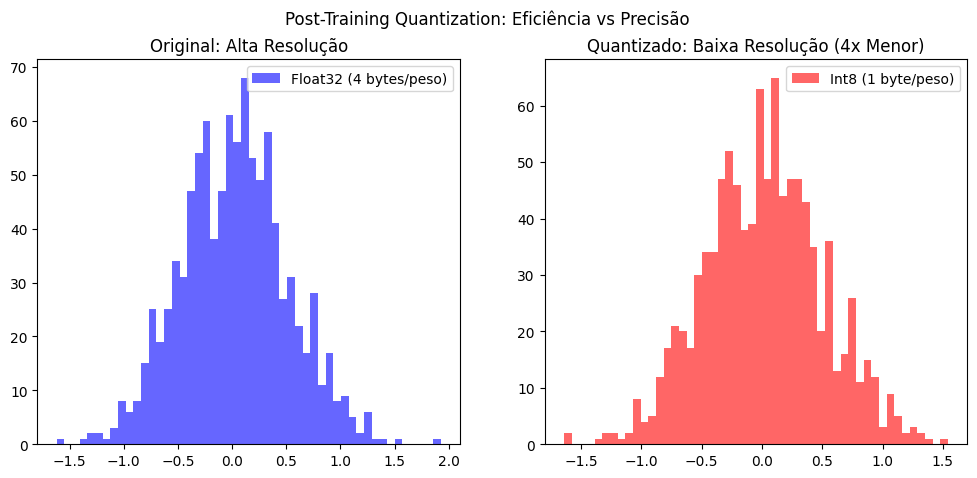

SOTA Tip: Em produção, usamos bibliotecas como TensorRT ou ONNX Runtime para fazer isso automaticamente.


In [46]:
# Experimento 5: O "Emagrecimento" do Modelo (Quantização)

def visualize_quantization_effect():
    # Simula pesos em alta precisão (Float32)
    weights_f32 = np.random.normal(0, 0.5, 1000).astype(np.float32)

    # Simula a Quantização para Int8 (256 níveis)
    # Na prática: w_int8 = round(w_float / scale + zero_point)
    scale = (weights_f32.max() - weights_f32.min()) / 255
    weights_i8 = np.round(weights_f32 / scale).astype(np.int8)

    # De-quantização para ver a perda de informação
    weights_recovered = weights_i8.astype(np.float32) * scale

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].hist(weights_f32, bins=50, color='blue', alpha=0.6, label='Float32 (4 bytes/peso)')
    ax[0].set_title("Original: Alta Resolução")
    ax[0].legend()

    # O gráfico Int8 mostra "degraus" (discretização)
    ax[1].hist(weights_recovered, bins=50, color='red', alpha=0.6, label='Int8 (1 byte/peso)')
    ax[1].set_title("Quantizado: Baixa Resolução (4x Menor)")
    ax[1].legend()

    plt.suptitle("Post-Training Quantization: Eficiência vs Precisão")
    plt.show()

    print("SOTA Tip: Em produção, usamos bibliotecas como TensorRT ou ONNX Runtime para fazer isso automaticamente.")

visualize_quantization_effect()


## 12) Exercícios sugeridos

1. Incluir **otimização de threshold** com base em F1 na validação.  
2. Adicionar um quarto candidato com `SGD+Momentum` e comparar robustez.  
3. Implementar monitoramento simulado de drift (PSI/KL) entre treino e produção.  
4. Repetir o módulo com um dataset real seu e adaptar o checklist de produção.



EXERCÍCIO 1 - Otimização de threshold com base em F1 na validação
Melhor threshold na validação (F1): 0.45

IID  @0.50: {'acc': 0.942, 'f1': 0.9174, 'auc': 0.9704, 'brier': 0.0471, 'ece': 0.0218}
IID  @opt : {'acc': 0.944, 'f1': 0.9209, 'auc': 0.9704, 'brier': 0.0471, 'ece': 0.0218}
SHIFT@0.50: {'acc': 0.918, 'f1': 0.8825, 'auc': 0.9708, 'brier': 0.0581, 'ece': 0.0222}
SHIFT@opt : {'acc': 0.918, 'f1': 0.8839, 'auc': 0.9708, 'brier': 0.0581, 'ece': 0.0222}


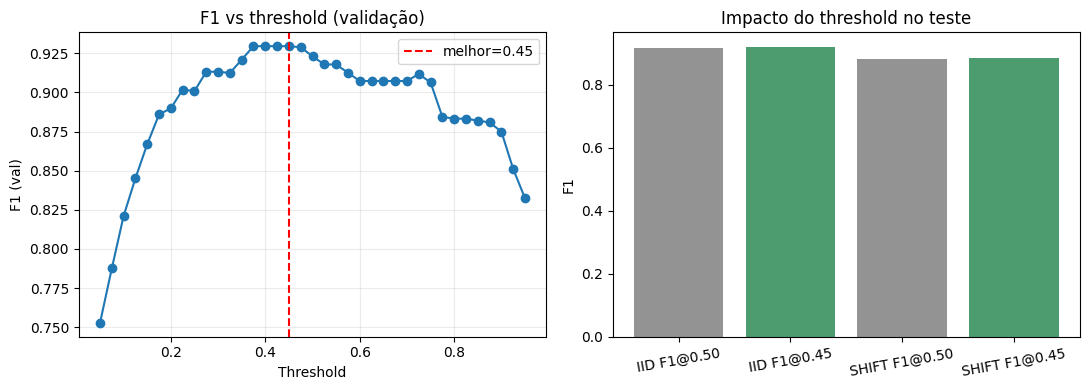

In [47]:
print("\n" + "="*72)
print("EXERCÍCIO 1 - Otimização de threshold com base em F1 na validação")
print("="*72)

# Probabilidades na validação interna do treino final
p_val_final = predict_proba_numpy(X_va_final, final_model.to(device), final_scaler, device=device)

thresholds = np.linspace(0.05, 0.95, 37)
rows_thr = []
for t in thresholds:
    m = compute_metrics(y_va_final, p_val_final, thr=float(t))
    rows_thr.append({"threshold": float(t), "f1": m["f1"], "acc": m["acc"], "auc": m["auc"], "ece": m["ece"]})

df_thr = pd.DataFrame(rows_thr)
best_thr = float(df_thr.sort_values("f1", ascending=False).iloc[0]["threshold"])

# Reavalia no teste IID e SHIFT com threshold padrão e otimizado
p_test_iid = predict_proba_numpy(X_test_iid, final_model.to(device), final_scaler, device=device)
p_test_shift = predict_proba_numpy(X_test_shift, final_model.to(device), final_scaler, device=device)

iid_050 = compute_metrics(y_test_iid, p_test_iid, thr=0.50)
iid_opt = compute_metrics(y_test_iid, p_test_iid, thr=best_thr)
shift_050 = compute_metrics(y_test_iid, p_test_shift, thr=0.50)
shift_opt = compute_metrics(y_test_iid, p_test_shift, thr=best_thr)

print(f"Melhor threshold na validação (F1): {best_thr:.2f}")
print("\nIID  @0.50:", {k: round(v, 4) for k, v in iid_050.items()})
print("IID  @opt :", {k: round(v, 4) for k, v in iid_opt.items()})
print("SHIFT@0.50:", {k: round(v, 4) for k, v in shift_050.items()})
print("SHIFT@opt :", {k: round(v, 4) for k, v in shift_opt.items()})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(df_thr["threshold"], df_thr["f1"], marker="o")
axes[0].axvline(best_thr, color="red", linestyle="--", label=f"melhor={best_thr:.2f}")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("F1 (val)")
axes[0].set_title("F1 vs threshold (validação)")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].bar(["IID F1@0.50", f"IID F1@{best_thr:.2f}", "SHIFT F1@0.50", f"SHIFT F1@{best_thr:.2f}"],
            [iid_050["f1"], iid_opt["f1"], shift_050["f1"], shift_opt["f1"]],
            color=["gray", "seagreen", "gray", "seagreen"], alpha=0.85)
axes[1].set_ylabel("F1")
axes[1].set_title("Impacto do threshold no teste")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


EXERCÍCIO 2 - Adicionar candidato SGD+Momentum e comparar robustez


,val_auc_mean,test_iid_auc_mean,test_shift_auc_mean,robust_gap_auc_mean
config,,,,
sgd_momentum,0.981844,0.969705,0.970008,-0.000303
alta_capacidade,0.981162,0.967880,0.969017,-0.001137
baseline,0.975226,0.964131,0.965361,-0.001230
regularizada,0.966055,0.956073,0.958318,-0.002245


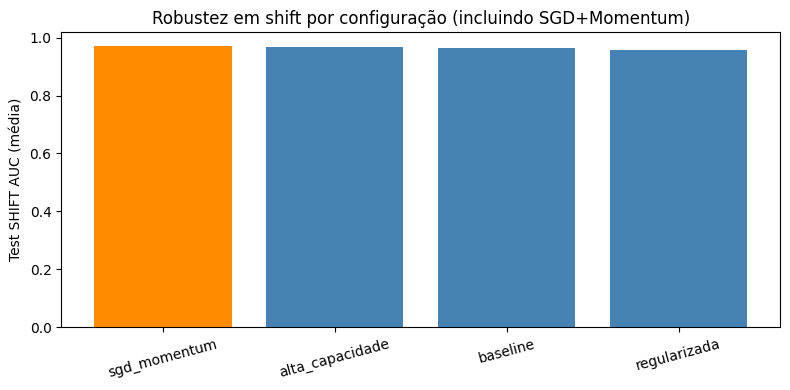


SGD+Momentum:
{'val_auc_mean': 0.9818439418586347, 'test_iid_auc_mean': 0.969704920326739, 'test_shift_auc_mean': 0.970008104341945, 'robust_gap_auc_mean': -0.00030318401520586696}


In [48]:
print("\n" + "="*72)
print("EXERCÍCIO 2 - Adicionar candidato SGD+Momentum e comparar robustez")
print("="*72)

# Versão estendida de treino para escolher otimizador

def train_one_run_opt(X_tr, y_tr, X_va, y_va, cfg, seed=42, max_epochs=40, patience=8):
    seed_everything(seed)

    train_loader, val_loader, scaler = make_loaders(
        X_tr, y_tr, X_va, y_va,
        batch_size=cfg["batch_size"],
        scaler=None,
        fit_scaler=True
    )

    model = MLP(
        input_dim=X_tr.shape[1],
        hidden_dim=cfg["hidden_dim"],
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"]
    ).to(device)

    opt_name = cfg.get("optimizer", "adamw").lower()
    if opt_name == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=cfg["lr"],
            momentum=cfg.get("momentum", 0.9),
            weight_decay=cfg["weight_decay"],
            nesterov=cfg.get("nesterov", True)
        )
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=cfg["lr"],
            weight_decay=cfg["weight_decay"]
        )

    scheduler = None
    if cfg.get("use_cosine", False):
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=cfg["lr"] * 0.05)

    best_state, best_val_loss, wait, best_epoch = None, float("inf"), 0, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = F.binary_cross_entropy_with_logits(model(xb), yb)
            loss.backward()
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        val_m = evaluate_loader(model, val_loader)
        if val_m["loss"] < best_val_loss - 1e-4:
            best_val_loss = val_m["loss"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    model.load_state_dict(best_state)
    final_val = evaluate_loader(model, val_loader)
    return model, scaler, final_val, best_epoch

# Novo candidato (4o): SGD+Momentum
configs_ext = dict(configs)
configs_ext["sgd_momentum"] = {
    "hidden_dim": 128,
    "num_layers": 3,
    "dropout": 0.10,
    "lr": 0.03,
    "weight_decay": 1e-4,
    "batch_size": 64,
    "use_cosine": True,
    "optimizer": "sgd",
    "momentum": 0.9,
    "nesterov": True,
}

rows_ext = []
for cfg_name, cfg in configs_ext.items():
    for s in seeds:
        model, scaler, val_m, best_ep = train_one_run_opt(X_train, y_train, X_val, y_val, cfg, seed=s, max_epochs=40, patience=8)

        _, test_iid_loader, _ = make_loaders(X_train, y_train, X_test_iid, y_test_iid, batch_size=256, scaler=scaler, fit_scaler=False)
        _, test_shift_loader, _ = make_loaders(X_train, y_train, X_test_shift, y_test_iid, batch_size=256, scaler=scaler, fit_scaler=False)

        iid_m = evaluate_loader(model, test_iid_loader)
        shift_m = evaluate_loader(model, test_shift_loader)

        rows_ext.append({
            "config": cfg_name,
            "seed": s,
            "val_auc": val_m["auc"],
            "test_iid_auc": iid_m["auc"],
            "test_shift_auc": shift_m["auc"],
            "robust_gap_auc": iid_m["auc"] - shift_m["auc"],
        })

df_ext = pd.DataFrame(rows_ext)
agg_ext = df_ext.groupby("config").agg(
    val_auc_mean=("val_auc", "mean"),
    test_iid_auc_mean=("test_iid_auc", "mean"),
    test_shift_auc_mean=("test_shift_auc", "mean"),
    robust_gap_auc_mean=("robust_gap_auc", "mean"),
).sort_values(["test_shift_auc_mean", "robust_gap_auc_mean"], ascending=[False, True])

display(agg_ext)

plt.figure(figsize=(8, 4))
order = agg_ext.index.tolist()
plt.bar(order, agg_ext.loc[order, "test_shift_auc_mean"], color=["steelblue" if c != "sgd_momentum" else "darkorange" for c in order])
plt.ylabel("Test SHIFT AUC (média)")
plt.title("Robustez em shift por configuração (incluindo SGD+Momentum)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

if "sgd_momentum" in agg_ext.index:
    print("\nSGD+Momentum:")
    print(agg_ext.loc["sgd_momentum"].to_dict())


EXERCÍCIO 3 - Monitoramento simulado de drift (PSI/KL)
Features monitoradas: 20
Features em alerta (PSI>0.2 ou KL>0.1): 3


,feature,psi,kl,mean_ref,mean_prod,alerta
0,f0,0.151240,0.240166,0.101644,0.390098,True
3,f3,0.096101,0.077840,0.031315,0.215354,False
1,f1,0.093249,0.141287,0.533595,0.766355,True
6,f6,0.091683,0.063118,-0.021962,-0.039747,False
2,f2,0.090506,0.071196,-0.374400,-0.179839,False
4,f4,0.059708,0.207475,0.352699,0.656343,True
16,f16,0.045443,0.088035,0.040249,-0.071688,False
15,f15,0.040221,0.069197,0.002963,0.106230,False
7,f7,0.037013,0.032938,0.303208,0.498135,False
8,f8,0.028869,0.064174,0.024467,-0.011483,False


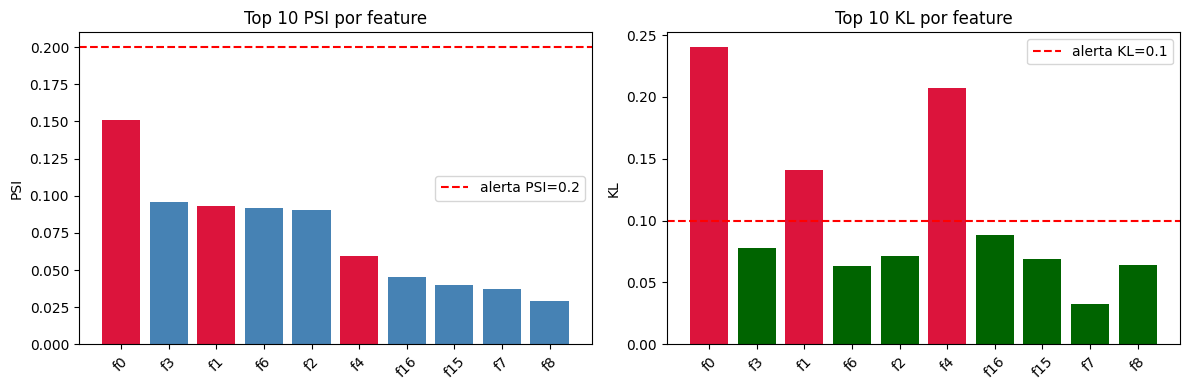

In [49]:
print("\n" + "="*72)
print("EXERCÍCIO 3 - Monitoramento simulado de drift (PSI/KL)")
print("="*72)

# Drift entre referência (treino) e produção (shift)
# Usando features reais do módulo para monitoramento.

def psi_score(ref, prod, bins=10, eps=1e-8):
    cuts = np.quantile(ref, np.linspace(0, 1, bins + 1))
    cuts[0] -= eps
    cuts[-1] += eps
    ref_hist, _ = np.histogram(ref, bins=cuts)
    prod_hist, _ = np.histogram(prod, bins=cuts)
    ref_pct = ref_hist / max(1, ref_hist.sum()) + eps
    prod_pct = prod_hist / max(1, prod_hist.sum()) + eps
    return float(np.sum((prod_pct - ref_pct) * np.log(prod_pct / ref_pct)))


def kl_divergence(ref, prod, bins=20, eps=1e-8):
    lo = min(ref.min(), prod.min())
    hi = max(ref.max(), prod.max())
    bins_arr = np.linspace(lo, hi, bins + 1)
    ref_hist, _ = np.histogram(ref, bins=bins_arr, density=True)
    prod_hist, _ = np.histogram(prod, bins=bins_arr, density=True)
    ref_hist = ref_hist + eps
    prod_hist = prod_hist + eps
    ref_hist = ref_hist / ref_hist.sum()
    prod_hist = prod_hist / prod_hist.sum()
    return float(np.sum(prod_hist * np.log(prod_hist / ref_hist)))

feature_rows = []
for j in range(X_train.shape[1]):
    r = X_train[:, j]
    p = X_test_shift[:, j]
    feature_rows.append({
        "feature": f"f{j}",
        "psi": psi_score(r, p, bins=10),
        "kl": kl_divergence(r, p, bins=20),
        "mean_ref": float(np.mean(r)),
        "mean_prod": float(np.mean(p)),
    })

df_drift = pd.DataFrame(feature_rows).sort_values("psi", ascending=False)

psi_alert = 0.20
kl_alert = 0.10
df_drift["alerta"] = (df_drift["psi"] > psi_alert) | (df_drift["kl"] > kl_alert)

print(f"Features monitoradas: {len(df_drift)}")
print(f"Features em alerta (PSI>{psi_alert} ou KL>{kl_alert}): {int(df_drift['alerta'].sum())}")
display(df_drift.head(10))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

top = df_drift.head(10)
axes[0].bar(top["feature"], top["psi"], color=["crimson" if a else "steelblue" for a in top["alerta"]])
axes[0].axhline(psi_alert, color="red", linestyle="--", label=f"alerta PSI={psi_alert}")
axes[0].set_title("Top 10 PSI por feature")
axes[0].set_ylabel("PSI")
axes[0].legend()

axes[1].bar(top["feature"], top["kl"], color=["crimson" if a else "darkgreen" for a in top["alerta"]])
axes[1].axhline(kl_alert, color="red", linestyle="--", label=f"alerta KL={kl_alert}")
axes[1].set_title("Top 10 KL por feature")
axes[1].set_ylabel("KL")
axes[1].legend()

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [50]:
import pandas as pd

print("\n" + "="*72)
print("EXERCÍCIO 4 - Repetir com dataset real e adaptar checklist de produção")
print("="*72)

try:
    path = '/Users/larissaiuki/Documents/GitHub/Pos-Deep-Learning/Otimização_ regularização_ajustes_de_modelos_profundos/Modulo8_artefatos_pipeline/Bank_Churn.csv'
    df_bank_churn = pd.read_csv(path)
    print("Dataset real carregado com sucesso!")
except Exception as e:
    print("Falha no download via KaggleHub:", repr(e))


EXERCÍCIO 4 - Repetir com dataset real e adaptar checklist de produção
Dataset real carregado com sucesso!


In [51]:
df_bank_churn.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [52]:
df_bank_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  str    
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  str    
 4   Gender           10000 non-null  str    
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), str(3)
memory usage: 1015.8 KB


In [54]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score

# Se você já carregou seu dataset em df_bank_churn, a célula usa ele automaticamente.
# Caso contrário, usa fallback reproduzível.
if "df_bank_churn" in globals() and isinstance(df_bank_churn, pd.DataFrame) and not df_bank_churn.empty:
    df_real = df_bank_churn.copy()
    dataset_name = "real_dataframe: df_bank_churn"

    target_candidates = ["Exited", "target", "churn", "Churn", "is_churn", "label", "y"]
    target_col = next((c for c in target_candidates if c in df_real.columns), None)
    if target_col is None:
        raise ValueError(
            "Não encontrei coluna alvo automaticamente. "
            "Renomeie sua coluna alvo para uma de: " + ", ".join(target_candidates)
        )

    # Remove colunas de identificador comuns em churn
    id_like_cols = [c for c in ["RowNumber", "CustomerId", "Surname", "CustomerID", "id", "ID"] if c in df_real.columns]
    X_real = df_real.drop(columns=[target_col] + id_like_cols)
    y_real = df_real[target_col].values

else:
    data = load_breast_cancer()
    X_real = pd.DataFrame(data.data, columns=data.feature_names)
    y_real = data.target
    dataset_name = "fallback: sklearn_breast_cancer"

# Split treino/teste
Xtr, Xte, ytr, yte = train_test_split(X_real, y_real, test_size=0.25, stratify=y_real, random_state=2026)

# Split interno para otimizar threshold por F1 (evita usar o teste para ajuste)
Xtr_fit, Xval_thr, ytr_fit, yval_thr = train_test_split(Xtr, ytr, test_size=0.20, stratify=ytr, random_state=2026)

# Pré-processamento misto (numérico + categórico)
num_cols = Xtr_fit.select_dtypes(include=["number"]).columns.tolist()
cat_cols = Xtr_fit.select_dtypes(exclude=["number"]).columns.tolist()

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preproc = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

# class_weight ajuda no desbalanceamento típico de churn
clf = Pipeline([
    ("prep", preproc),
    ("model", LogisticRegression(max_iter=12000, solver="saga", class_weight="balanced", random_state=2026))
])

clf.fit(Xtr_fit, ytr_fit)

# Threshold tuning em validação interna
p_val = clf.predict_proba(Xval_thr)[:, 1]
thresholds = np.linspace(0.10, 0.90, 33)
best_thr = 0.5
best_f1 = -1.0
for t in thresholds:
    f1_t = f1_score(yval_thr, (p_val >= t).astype(int))
    if f1_t > best_f1:
        best_f1 = f1_t
        best_thr = float(t)

# Avaliação no teste final
probs = clf.predict_proba(Xte)[:, 1]
preds_05 = (probs >= 0.5).astype(int)
preds_opt = (probs >= best_thr).astype(int)

print("Dataset usado:", dataset_name)
print("Shape X:", X_real.shape)
print("Colunas numéricas:", len(num_cols), "| categóricas:", len(cat_cols))
print(f"AUC: {roc_auc_score(yte, probs):.4f}")
print(f"F1 @0.50: {f1_score(yte, preds_05):.4f}")
print(f"Threshold ótimo (val): {best_thr:.2f}")
print(f"F1 @threshold ótimo: {f1_score(yte, preds_opt):.4f}")

Dataset usado: real_dataframe: df_bank_churn
Shape X: (10000, 10)
Colunas numéricas: 8 | categóricas: 2
AUC: 0.7692
F1 @0.50: 0.4950
Threshold ótimo (val): 0.53
F1 @threshold ótimo: 0.4908
